## The standard stack: importing packages + reading in the data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## Groupby

As we learned, `.groupby` is a super useful way to aggregate the data and explore summary statistics. We can assign the output to a new dataframe, just taking the n largest amounts. Resetting the index just changes the index to integers starting at 0. 

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>


In [2]:
gift_totals = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum()
gift_totals.sort_values(ascending=False).head(1)

Country of Giftor
QATAR    2706240869
Name: Foreign Gift Amount, dtype: int64

**Q1:** `Qatar` gives the most money, with a total of `$2.71B`.

In [29]:
gift_totals.nlargest(10)

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
CANADA           898160656
HONG KONG        887402529
JAPAN            655954776
SWITZERLAND      619899445
INDIA            539556490
Name: Foreign Gift Amount, dtype: int64

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


In [3]:
gift_counts = df.groupby('Country of Giftor').count()['ID']
gift_counts.sort_values(ascending=False).head(1)

Country of Giftor
ENGLAND    3655
Name: ID, dtype: int64

**Q2:** `England` has given the most gifts, with a count of `3,655`.

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

In [4]:
gift_averages = df.groupby('Country of Giftor')['Foreign Gift Amount'].mean()
gift_averages.sort_values(ascending=False).head(1)

Country of Giftor
BERMUDA    7.688837e+06
Name: Foreign Gift Amount, dtype: float64

**Q3:** `Bermuda` gives the largest average gifts, with an average of `$7.69M`.

## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

In [5]:
institution_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
institution_totals.sort_values(ascending=False).head(1)

Institution Name
Carnegie Mellon University    1477922504
Name: Foreign Gift Amount, dtype: int64

**Q4:** `Carnegie Mellon` receives the most money, with a total of `$1.48B`.

In [6]:
institution_counts = df.groupby('Institution Name').count()['ID']
institution_counts.sort_values(ascending=False).head(1)

Institution Name
University of California, Los Angeles    3916
Name: ID, dtype: int64

**Q5:** `UCLA` receives the most gifts, with a total of `3,916`.

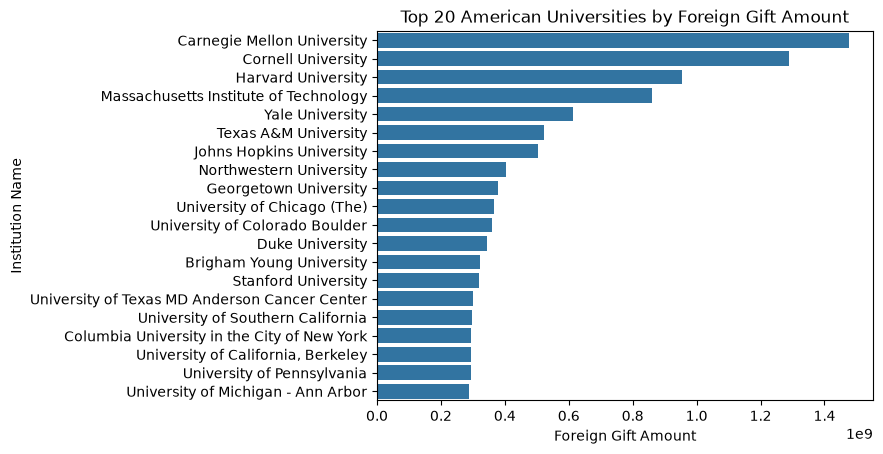

In [7]:
top_totals = institution_totals.sort_values(ascending=False).head(20)

sns.barplot(x="Foreign Gift Amount", y="Institution Name", data=top_totals.to_frame())
plt.title("Top 20 American Universities by Foreign Gift Amount")
plt.show()

## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


In [8]:
amount_mean = institution_totals.mean()
amount_median = institution_totals.median()
print(f"Mean: {amount_mean:.1f}, Median: {amount_median:.1f}")

Mean: 52202879.0, Median: 6486791.5


**Q6:** The mean is `$52.2M`, while the median is `$6.5M`.

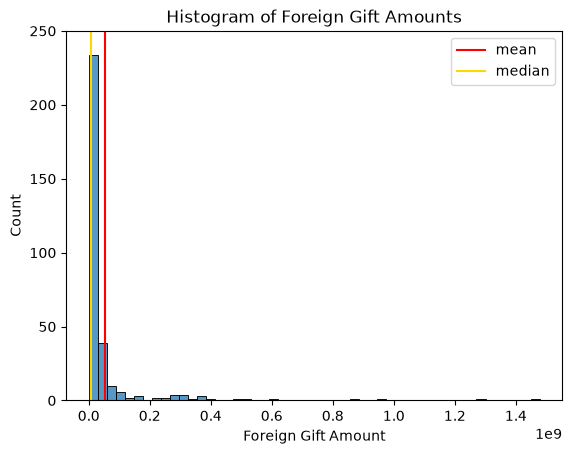

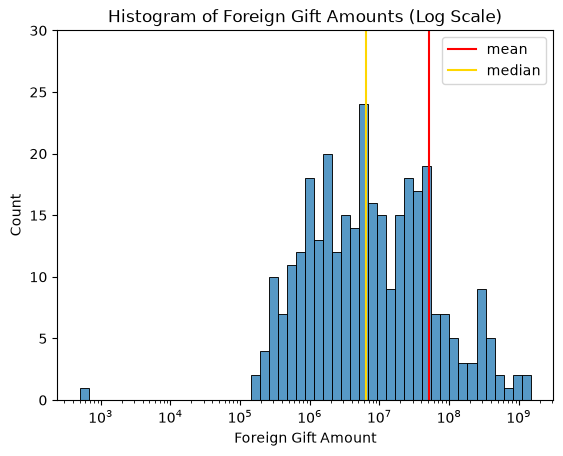

In [9]:
# Normal Scale
sns.histplot(institution_totals, bins=50)
plt.plot([amount_mean, amount_mean], [0, 250], c='red', label='mean')
plt.plot([amount_median, amount_median], [0, 250], c='gold', label='median')

plt.title('Histogram of Foreign Gift Amounts')
plt.legend()
plt.ylim(top=250)
plt.show()

# Log Scale
sns.histplot(institution_totals, bins=50, log_scale=True)
plt.plot([amount_mean, amount_mean], [0, 250], c='red', label='mean')
plt.plot([amount_median, amount_median], [0, 250], c='gold', label='median')

plt.title('Histogram of Foreign Gift Amounts (Log Scale)')
plt.xlabel('Foreign Gift Amount')
plt.legend()
plt.ylim(top=30)
plt.show()

The mean is much larger than the median, which makes sense because the distribution is heavily right-tailed. The most gifted universities make orders of magnitude more than others, which overinflates the mean but does not affect the median.

## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [10]:
cross = pd.crosstab(df['Country of Giftor'], df['Institution Name'])
cross

Institution Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMERICAN SAMOA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANGOLA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANTIGUA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ARGENTINA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
WALES,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
YEMEN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
country_institution_counts = df.groupby(['Country of Giftor', 'Institution Name'])['ID'].count()
country_institution_counts.sort_values(ascending=False).head(1)

Country of Giftor  Institution Name                     
ENGLAND            University of California, Los Angeles    964
Name: ID, dtype: int64

**Q7:** The top flow of total gifts goes from `England` to `UCLA`.

### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

In [12]:
import plotly.graph_objects as go

giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()



<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>


In [13]:
df.groupby('Giftor Name')['Foreign Gift Amount'].count().sort_values(ascending=False).head(5)

Giftor Name
Saudi Arabian Cultural Mission    480
Human Frontier Science Program    287
Anonymous                         262
Qatar Foundation                  261
Novartis Pharmaceuticals Corp     251
Name: Foreign Gift Amount, dtype: int64

**Q8:** The top 5 giftors by number of gifts are `Saudi Arabian Cultural Mission`, `Human Frontier Science Program`, `Anonymous`, `Qatar Foundation`, and `Novartis Pharmaceuticals Corp`.